# nb00 — фундамент: универсум, качество данных, масштаб костов

**Здесь нет стратегии и нет гипотезы про edge.** Единственная задача — узнать,
с каким материалом мы работаем, до того как считать хоть один спред. Если
пропустить этот шаг, любая последующая находка может оказаться артефактом
битых/несинхронных/неликвидных данных.

Что устанавливаем:
1. **Универсум** — сколько символов и почему именно они; насколько велико
   смещение выжившего (survivorship).
2. **Качество панели** — дырки, залипшие (stale) бары, аномальные доходности.
3. **Ликвидность** — распределение $-объёма; кого честно нельзя торговать.
4. **Масштаб костов против масштаба движений** — 21 bps round-trip это много
   или мало относительно того, как эти активы шевелятся на разных горизонтах.
   Это задаёт нижнюю границу горизонта для всей линии.

In [1]:
import sys; sys.path.insert(0, ".")
from _lab import *

print("ОКНА ИССЛЕДОВАНИЯ")
for nm, w in [("FULL ", FULL), ("TRAIN", TRAIN), ("OOS  ", OOS)]:
    d = (pd.Timestamp(w[1]) - pd.Timestamp(w[0])).days
    print(f"  {nm}  {w[0]} .. {w[1]}   {d:>4} дней = {d/30.44:5.1f} мес")

print("\nКОСТЫ (приняты)")
print(f"  fee {FEE_BPS} bps + slippage {SLIP_BPS} bps = {SIDE_BPS} bps за одно пересечение gross notional")
print(f"  round-trip (вход+выход) = {ROUND_TRIP_BPS} bps = {ROUND_TRIP_BPS/100:.2f}% от gross notional")
print("\nПроверка, что OOS реально заперт:")
try:
    oos_slice(pd.DataFrame(index=pd.DatetimeIndex([], tz="UTC")))
except RuntimeError as e:
    print("  OK, исключение:", str(e)[:70], "...")

ОКНА ИССЛЕДОВАНИЯ
  FULL   2024-01-01 .. 2026-05-01    851 дней =  28.0 мес
  TRAIN  2024-01-01 .. 2025-07-01    547 дней =  18.0 мес
  OOS    2025-07-01 .. 2026-05-01    304 дней =  10.0 мес

КОСТЫ (приняты)
  fee 5.5 bps + slippage 5.0 bps = 10.5 bps за одно пересечение gross notional
  round-trip (вход+выход) = 21.0 bps = 0.21% от gross notional

Проверка, что OOS реально заперт:
  OK, исключение: OOS is locked. Pass unlock='<which frozen rule you are testing>' and r ...


## 1. Универсум и смещение выжившего

Универсум = символы с **полным** набором месячных parquet на окне
2024-01 … 2026-04. Это по построению «выжившие»: всё, что делистнули по ходу,
в панель не попало. Меряем, сколько таких выпавших и когда они пропали.

In [2]:
all_syms = list_symbols()
uni = universe()
cov = {s: coverage(s) for s in all_syms}

print(f"всего папок с 1m-данными : {len(all_syms)}")
print(f"универсум (полное покрытие 2024-01..2026-04): {len(uni)}")

rest = [s for s in all_syms if s not in set(uni)]
late = [s for s in rest if min(cov[s]) > "2024-01"]          # листинг позже начала окна
early_end = [s for s in rest if max(cov[s]) < "2026-04"]      # пропали до конца окна
holes = [s for s in rest if min(cov[s]) <= "2024-01" and max(cov[s]) >= "2026-04"]
print(f"\nне попали в универсум: {len(rest)}")
print(f"  из них листинг ПОЗЖЕ 2024-01      : {len(late)}")
print(f"  из них история КОНЧАЕТСЯ до 2026-04: {len(early_end)}  <- кандидаты в 'умершие'")
print(f"  из них дырка в середине            : {len(holes)}")

if early_end:
    ends = pd.Series([max(cov[s]) for s in early_end]).value_counts().sort_index()
    print("\nкогда кончается история у выпавших (последний месяц -> сколько символов):")
    print(ends.to_string())
    print("\nпримеры:", ", ".join(f"{s}({max(cov[s])})" for s in early_end[:12]))

surv_bias = len(early_end) / (len(uni) + len(early_end)) * 100
print(f"\nдоля 'умерших' от (универсум + умершие) = {surv_bias:.1f}%")
print("  -> это и есть масштаб survivorship-смещения нашего универсума")

всего папок с 1m-данными : 234
универсум (полное покрытие 2024-01..2026-04): 140

не попали в универсум: 94
  из них листинг ПОЗЖЕ 2024-01      : 61
  из них история КОНЧАЕТСЯ до 2026-04: 25  <- кандидаты в 'умершие'
  из них дырка в середине            : 8

когда кончается история у выпавших (последний месяц -> сколько символов):
2024-02    1
2024-03    1
2024-04    1
2024-07    1
2024-09    1
2024-10    1
2024-11    1
2024-12    2
2025-01    1
2025-02    1
2025-04    1
2025-06    3
2025-07    1
2025-08    2
2025-09    1
2025-12    2
2026-01    2
2026-02    1
2026-03    1

примеры: 10000SATSUSDT(2025-06), 1000BTTUSDT(2025-09), 1000FLOKIUSDT(2025-08), 1000LUNCUSDT(2025-07), 1000RATSUSDT(2025-06), 1000XECUSDT(2025-06), BLURUSDT(2025-02), BNTUSDT(2025-01), BOBAUSDT(2024-11), CYBERUSDT(2025-12), DUSKUSDT(2024-10), EDUUSDT(2024-03)

доля 'умерших' от (универсум + умершие) = 15.2%
  -> это и есть масштаб survivorship-смещения нашего универсума


## 2. Качество панели

Три вопроса к матрице цен:
- **дырки**: все ли часы на месте у всех символов (иначе «выравнивание» пары
  тихо съест часть истории);
- **stale-бары**: доля часов с нулевой доходностью — прокси неликвидности
  (цена не двигалась вообще). Для арбитража это яд: спред «стационарен»
  просто потому, что одна нога не торгуется;
- **аномалии**: экстремальные часовые доходности — либо реальные события,
  либо битые тики; и то и другое ломает регрессии.

In [3]:
px = load_panel("close", "1h")
dv = load_panel("dollarvol", "1h")
print(f"панель close 1h: {px.shape[0]} часов x {px.shape[1]} символов")
print(f"  {px.index[0]}  ..  {px.index[-1]}")

expected = pd.date_range(FULL[0], FULL[1], freq="1h", inclusive="left", tz="UTC")
print(f"\nожидалось часов в окне: {len(expected)}; в индексе: {len(px.index)}")
print(f"  часов, которых нет в индексе вообще: {len(expected.difference(px.index))}")

nan_share = px.isna().mean().mul(100)
print(f"\nNaN (нет цены) по символам, % часов:")
print(f"  медиана {nan_share.median():.3f}%   максимум {nan_share.max():.3f}% ({nan_share.idxmax()})")
print(f"  символов с >1% дырок: {(nan_share > 1).sum()}")
print("  худшие 8:")
print(nan_share.sort_values(ascending=False).head(8).round(3).to_string())

панель close 1h: 20424 часов x 140 символов
  2024-01-01 00:00:00+00:00  ..  2026-04-30 23:00:00+00:00

ожидалось часов в окне: 20424; в индексе: 20424
  часов, которых нет в индексе вообще: 0

NaN (нет цены) по символам, % часов:
  медиана 0.000%   максимум 0.000% (API3USDT)
  символов с >1% дырок: 0
  худшие 8:
API3USDT       0.0
ARKUSDT        0.0
ARPAUSDT       0.0
ARUSDT         0.0
ASTRUSDT       0.0
ATOMUSDT       0.0
AUCTIONUSDT    0.0
AVAXUSDT       0.0


In [4]:
ret = np.log(px).diff()

flat = ret.eq(0).mean().mul(100)              # доля часов без движения цены
absret = ret.abs()
q = pd.DataFrame({
    "nan_%": nan_share.round(2),
    "flat_%": flat.round(2),
    "med|r1h|_bps": (absret.median() * 1e4).round(1),
    "max|r1h|_%": (absret.max() * 100).round(1),
    "med_$vol/h": dv.median().round(0),
})

print("STALE-БАРЫ (доля часов с нулевой доходностью), %:")
print(f"  медиана по универсуму {flat.median():.2f}%   "
      f"q90 {flat.quantile(.9):.2f}%   максимум {flat.max():.2f}% ({flat.idxmax()})")
print(f"  символов с flat > 5%: {(flat > 5).sum()};  > 10%: {(flat > 10).sum()}")
print("\nхудшие 12 по stale (кандидаты на исключение):")
print(q.sort_values("flat_%", ascending=False).head(12).to_string())

print("\nАНОМАЛИИ: символы с самой большой одночасовой доходностью:")
print(q.sort_values("max|r1h|_%", ascending=False).head(8).to_string())
print(f"\nвсего часов с |r| > 20% по всей панели: {(absret > 0.20).sum().sum()}")
print(f"всего часов с |r| > 50% по всей панели: {(absret > 0.50).sum().sum()}")

STALE-БАРЫ (доля часов с нулевой доходностью), %:
  медиана по универсуму 1.30%   q90 2.67%   максимум 48.79% (USDCUSDT)
  символов с flat > 5%: 2;  > 10%: 1

худшие 12 по stale (кандидаты на исключение):
           nan_%  flat_%  med|r1h|_bps  max|r1h|_%  med_$vol/h
USDCUSDT     0.0   48.79           1.0         0.2     19407.0
PAXGUSDT     0.0    9.17           8.5        15.1     84207.0
JSTUSDT      0.0    3.59          24.6        22.5     18906.0
STEEMUSDT    0.0    3.43          40.1        18.7     21368.0
RVNUSDT      0.0    3.18          46.6        54.8     39999.0
BATUSDT      0.0    3.09          45.4        13.4     38565.0
ORBSUSDT     0.0    3.01          38.1        18.3     26855.0
GODSUSDT     0.0    2.99          52.1        40.2     13944.0
FLRUSDT      0.0    2.97          44.9        25.5     36632.0
OGNUSDT      0.0    2.89          48.7        32.9     25681.0
IOTAUSDT     0.0    2.81          49.7        31.9     80800.0
TUSDT        0.0    2.73          42.6 

## 3. Ликвидность

Гипотеза пользователя опирается на слово **ликвидных** («корзин найдётся
больше среди ликвидных»). Значит надо сразу знать, как ликвидность
распределена: сколько у нас реально торгуемых активов, а сколько — витрина.

In [5]:
mdv = dv.median()                       # медианный $-объём в час
daily = mdv * 24 / 1e6                  # ~$ млн в день
print("МЕДИАННЫЙ ОБЪЁМ, $ млн/день (по часовой медиане x24):")
for p in [1, 5, 10, 25, 50, 75, 90, 99]:
    print(f"  q{p:>2}: {daily.quantile(p/100):9.2f}")

for thr in [1, 5, 20, 100]:
    print(f"  символов с >= ${thr} млн/день: {(daily >= thr).sum():>3}")

print("\nТОП-12 по объёму:")
print(q.assign(**{"$M/day": daily.round(1)}).sort_values("$M/day", ascending=False)
       .head(12)[["$M/day", "flat_%", "med|r1h|_bps"]].to_string())
print("\nДНО-12 по объёму:")
print(q.assign(**{"$M/day": daily.round(2)}).sort_values("$M/day")
       .head(12)[["$M/day", "flat_%", "med|r1h|_bps"]].to_string())

МЕДИАННЫЙ ОБЪЁМ, $ млн/день (по часовой медиане x24):
  q 1:      0.29
  q 5:      0.45
  q10:      0.57
  q25:      0.96
  q50:      1.87
  q75:     10.02
  q90:     32.65
  q99:   1741.95
  символов с >= $1 млн/день:  98
  символов с >= $5 млн/день:  43
  символов с >= $20 млн/день:  21
  символов с >= $100 млн/день:   5

ТОП-12 по объёму:
          $M/day  flat_%  med|r1h|_bps
BTCUSDT   5324.5    0.01          22.1
ETHUSDT   2591.1    0.05          31.1
XRPUSDT    413.8    0.85          34.2
DOGEUSDT   264.5    0.48          43.7
SUIUSDT    162.4    0.34          55.8
LINKUSDT    76.3    0.39          45.2
AVAXUSDT    72.2    0.69          46.9
NEARUSDT    57.0    1.35          55.9
BNBUSDT     51.7    1.31          26.7
WLDUSDT     49.3    1.33          62.4
TIAUSDT     37.8    1.33          62.3
SEIUSDT     36.0    1.53          57.3

ДНО-12 по объёму:
           $M/day  flat_%  med|r1h|_bps
OXTUSDT      0.26    0.93          48.9
SCRTUSDT     0.29    1.86          55.5
REQUSDT   

[saved] notebooks\statarb\_out\nb00_liquidity.png


WindowsPath('C:/projects/researchlab/notebooks/statarb/_out/nb00_liquidity.png')

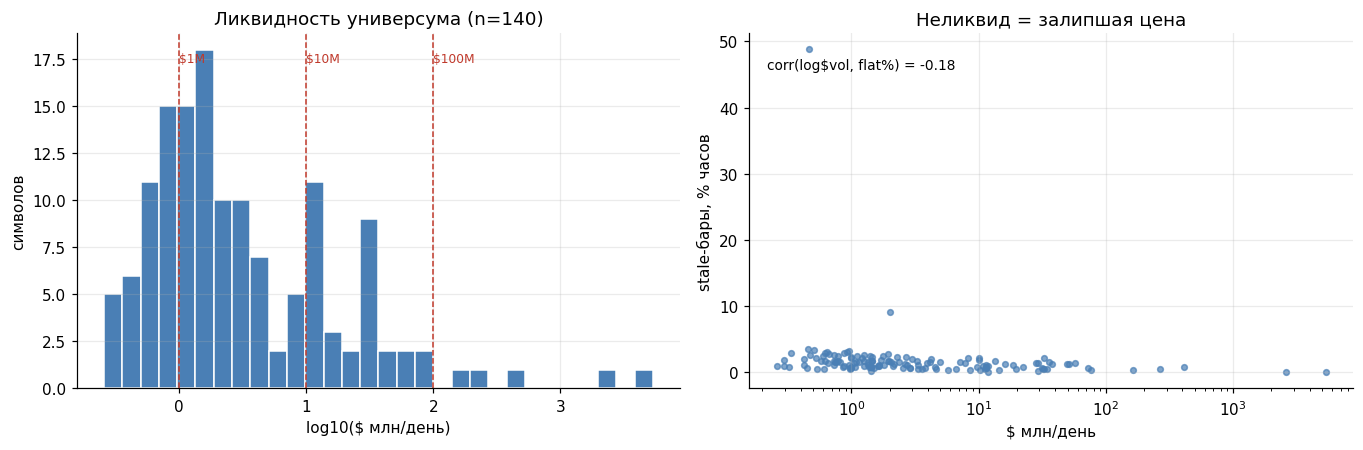

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.2))
ax[0].hist(np.log10(daily.clip(lower=0.01)), bins=30, color="#4a7fb5", edgecolor="white")
ax[0].set_xlabel("log10($ млн/день)"); ax[0].set_ylabel("символов")
ax[0].set_title(f"Ликвидность универсума (n={len(daily)})")
for t, lab in [(1, "$1M"), (10, "$10M"), (100, "$100M")]:
    ax[0].axvline(np.log10(t), color="#c0392b", ls="--", lw=1)
    ax[0].text(np.log10(t), ax[0].get_ylim()[1]*0.92, lab, color="#c0392b", fontsize=8)

ax[1].scatter(daily, flat, s=14, alpha=0.7, color="#4a7fb5")
ax[1].set_xscale("log"); ax[1].set_xlabel("$ млн/день"); ax[1].set_ylabel("stale-бары, % часов")
ax[1].set_title("Неликвид = залипшая цена")
rho = np.corrcoef(np.log10(daily.clip(lower=0.01)), flat)[0, 1]
ax[1].text(0.03, 0.9, f"corr(log$vol, flat%) = {rho:+.2f}", transform=ax[1].transAxes, fontsize=9)
show("nb00_liquidity")

## 4. Косты против движений: какой горизонт вообще может платить

Round-trip 21 bps от gross notional — это фиксированный барьер. Чтобы понять,
на каком горизонте мы вообще имеем право искать edge, сравниваем барьер с тем,
**насколько сильно шевелятся сами активы** на разных горизонтах.

Считаем медианную |доходность| одного актива на 1h / 4h / 1d / 3d и смотрим
отношение к 21 bps. Это ещё не про спред (спред тише отдельного актива, потому
что общий рыночный фактор вычтен) — но даёт верхнюю границу и порядок величин.

In [7]:
rows = []
for tf, bars in [("1h", 1), ("4h", 4), ("1d", 24), ("3d", 72)]:
    r = np.log(px).diff(bars)
    med = r.abs().median().median() * 1e4        # bps, медиана по времени и по символам
    sd = r.std().median() * 1e4
    rows.append({"горизонт": tf, "med|r|_bps": round(med, 1), "std_r_bps": round(sd, 1),
                 "med|r| / 21bps": round(med / ROUND_TRIP_BPS, 2),
                 "std / 21bps": round(sd / ROUND_TRIP_BPS, 2)})
hz = pd.DataFrame(rows)
print("РАЗМАХ ДВИЖЕНИЯ ОДНОГО АКТИВА vs ROUND-TRIP 21 bps")
print(hz.to_string(index=False))

print("\nТо же по группам ликвидности (медиана |r| на 1d, bps):")
grp = pd.qcut(daily, 3, labels=["низ", "серед", "верх"])
r1d = np.log(px).diff(24).abs().median() * 1e4
print(r1d.groupby(grp, observed=True).median().round(1).to_string())

РАЗМАХ ДВИЖЕНИЯ ОДНОГО АКТИВА vs ROUND-TRIP 21 bps
горизонт  med|r|_bps  std_r_bps  med|r| / 21bps  std / 21bps
      1h        49.5      113.2            2.36         5.39
      4h        98.0      223.9            4.66        10.66
      1d       267.9      534.9           12.76        25.47
      3d       480.2      902.5           22.87        42.97

То же по группам ликвидности (медиана |r| на 1d, bps):
низ      248.3
серед    269.3
верх     277.7


первый общий час: 2024-01-01 00:00:00+00:00 | последний: 2026-04-30 23:00:00+00:00
итог к концу окна (x раз):
BTCUSDT     1.79
ETHUSDT     0.98
XRPUSDT     2.22
DOGEUSDT    1.18


[saved] notebooks\statarb\_out\nb00_sanity.png


WindowsPath('C:/projects/researchlab/notebooks/statarb/_out/nb00_sanity.png')

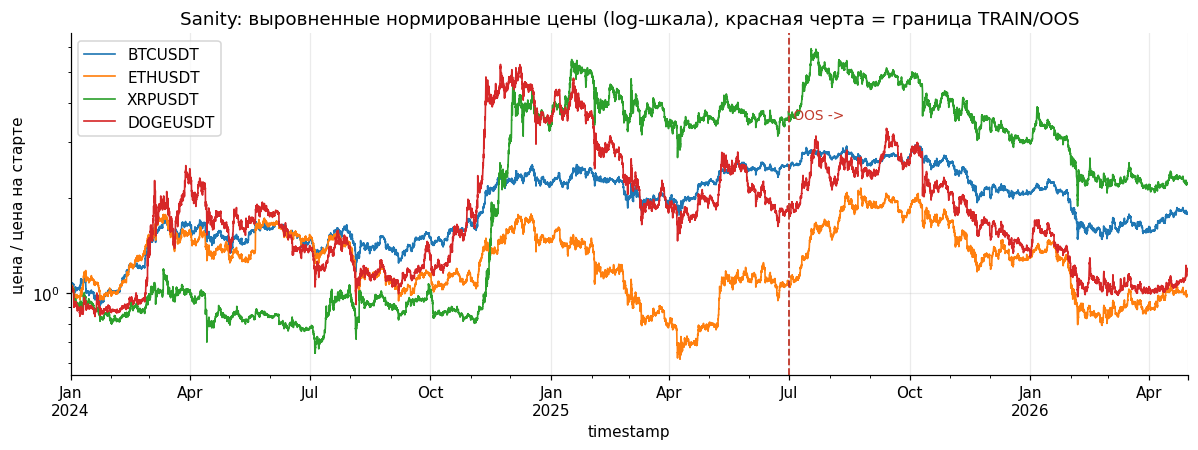

In [8]:
# Sanity-чек выравнивания панели: нормированные пути нескольких мажоров.
# Если панель собрана правильно, линии стартуют из 1.0 в один и тот же час.
sel = [s for s in ["BTCUSDT", "ETHUSDT", "SOLUSDT", "XRPUSDT", "DOGEUSDT"] if s in px.columns]
sub = px[sel].dropna()
norm = sub / sub.iloc[0]
ax = norm.plot(logy=True, lw=1.1)
ax.axvline(pd.Timestamp(TRAIN[1], tz="UTC"), color="#c0392b", ls="--", lw=1.2)
ax.text(pd.Timestamp(TRAIN[1], tz="UTC"), norm.max().max()*0.6, " OOS ->", color="#c0392b", fontsize=9)
ax.set_title("Sanity: выровненные нормированные цены (log-шкала), красная черта = граница TRAIN/OOS")
ax.set_ylabel("цена / цена на старте")
print("первый общий час:", sub.index[0], "| последний:", sub.index[-1])
print("итог к концу окна (x раз):")
print(norm.iloc[-1].round(2).to_string())
show("nb00_sanity")